<a href="https://colab.research.google.com/github/flzhfi/deep-learning-assignments/blob/main/week06-CNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##**[6주차]과제**
- 아래의 과제1), 과제2)의 코드를 완성하시오.
- 모든 코드의 결과를 출력하여, .ipynb의 링크를 **[6주차]/[6주차]과제**에 제출하시오.\
(실습 제출 예시: 6주차_2020XXXX_이름.ipynb 코드 링크)

In [ ]:
print("2353764", "신예진")

2353764 신예진


In [ ]:
from google.colab import auth

auth.authenticate_user()
!gcloud config get-value account

snayou2@gmail.com


# Baseline 모델 구조
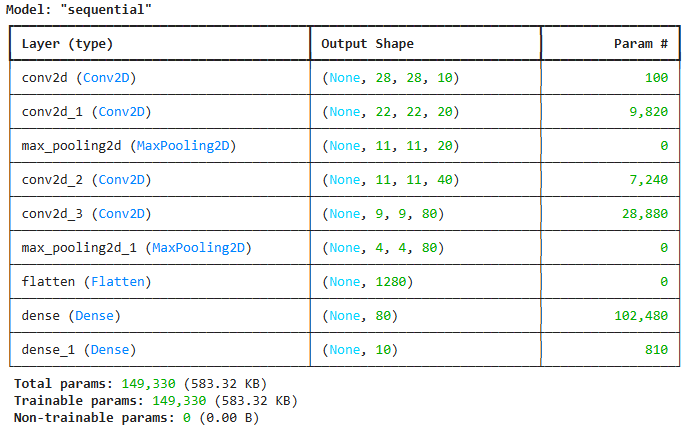

# [과제 1] Baseline 모델 구조에 표기되어있는 baseline 구조와 동일하게 모델 구축한 뒤 코드 model.summary()를 출력하여 나온 model 구조를 캡처 및 제출

## 조건 :
1. Conv2D 함수 안의 파라미터를 조정하여 표기되어있는 baseline 구조와 동일하게 모델 구축

    예시) layer추가
```python
# 입력 Conv2D layer 함수 예시
model.add(layers.Conv2D(filter, kernel_size, activation='activation', padding='valid or same', input_shape=(train_img.shape과 동일), kernel_initializer=initializer))
# Conv2D layer 함수 예시
model.add(layers.Conv2D(filter, kernel_size, activation='activation', padding='valid or same', kernel_initializer=initializer))



## model.summary() 코드를 실행한 뒤 나온 출력 결과물을 캡처하여 아래의 '모델 구조 summary 사진 업로드' 부분에 업로드

### - 모델 구조 summary 사진 업로드:
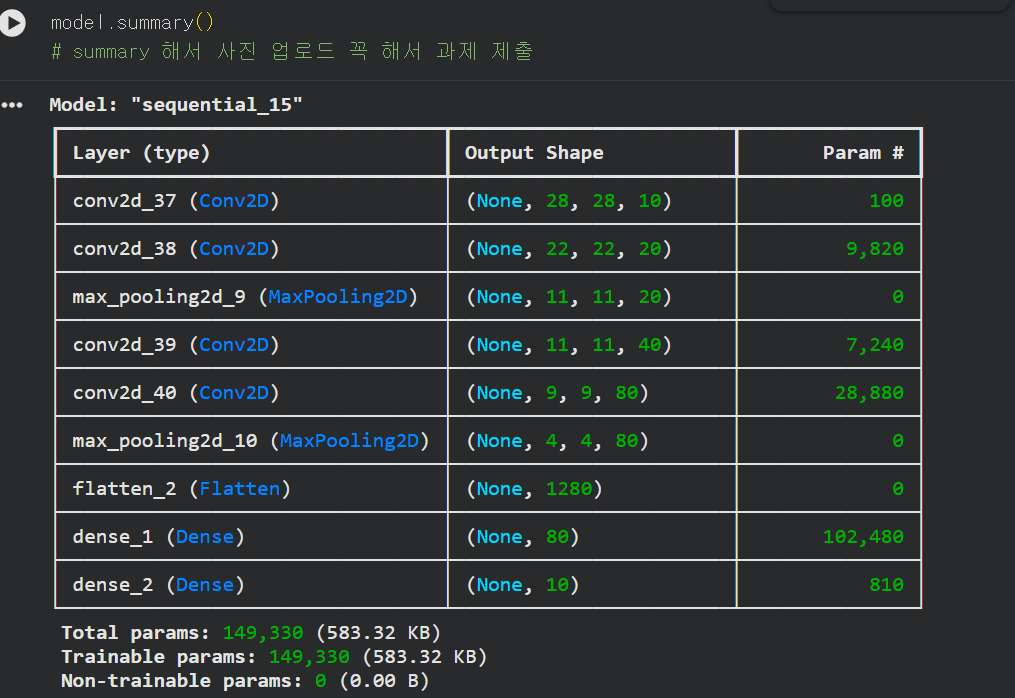

# [과제 2] Baseline 모델 구조 변경 또는 Hyper-parameter를 변경하여 accuracy 0.85이상 달성
## 조건 :
1. epoch 수는 최대 3으로 제한
2. Conv2D kerner_size, padding, avtivation_func, optimizer만 수정


In [ ]:
import os
import tensorflow as tf
from tensorflow.keras import datasets, layers, models, initializers

In [ ]:
# GPU 확인
!nvidia-smi

Wed Apr  8 03:54:01 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   77C    P0             37W /   70W |    1153MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# 실험 결과 재현을 위한 seed 고정
seed = 4
os.environ['PYTHONHASHSEED'] = str(seed)
tf.random.set_seed(seed)
initializer = tf.keras.initializers.GlorotUniform(seed=seed)

In [ ]:
# 데이터셋 불러오기
(train_images, train_labels), (test_images, test_labels) = tf.keras.datasets.fashion_mnist.load_data()

In [ ]:
# 데이터셋 전처리
train_images = train_images.reshape((60000, 28, 28, 1))
test_images = test_images.reshape((10000, 28, 28, 1))

train_images, test_images = train_images / 255.0, test_images / 255.0

In [ ]:
# Convolution neural network 생성
def build_model():
  # 코드를 작성해주세요
  # 힌트 : Conv layer의 kernel_size, padding 조합 필요
  model = models.Sequential()

  '''여기에 코드 작성'''
  model.add(layers.Conv2D(10, (3,3), activation='relu', input_shape=(28, 28, 1), padding='same'))
  model.add(layers.Conv2D(20, (3,3), activation='relu', padding='valid'))

  model.add(layers.MaxPooling2D((2,2)))
  model.add(layers.Conv2D(40, (3,3), activation='relu', padding='same'))

  model.add(layers.Conv2D(80, (3,3), activation='relu', padding='valid'))
  model.add(layers.MaxPooling2D((2,2)))

  model.add(layers.Flatten())

  model.add(layers.Dense(80, activation='relu'))
  model.add(layers.Dense(10, activation='softmax'))

  return model

In [ ]:
model = build_model()

In [ ]:
model.summary()
# summary 해서 사진 업로드 꼭 해서 과제 제출

Model: "sequential_19"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_53 (Conv2D)              │ (None, 28, 28, 10)     │           100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 26, 26, 20)     │         1,820 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 13, 13, 20)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 13, 13, 40)     │         7,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 11, 11, 80)     │        28,880 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_18 (MaxPooling2D) │ (None, 5, 5, 80)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 2000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 80)             │       160,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │           810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 198,930 (777.07 KB)

 Trainable params: 198,930 (777.07 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
model.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

model.fit(train_images, train_labels, epochs=3)

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8382 - loss: 0.4438
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8968 - loss: 0.2795
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9160 - loss: 0.2299


In [ ]:
test_loss, test_acc = model.evaluate(test_images, test_labels)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9075 - loss: 0.2528


In [ ]:
print('테스트 정확도 : ', round(test_acc,2))

테스트 정확도 :  0.91
